# **Atividade Prática**
<font size=3>

- **Tema:** redes recorrentes.
- **Prazo de entrega:** 08 de Junho.

**Envie** o notebook **executado** em formato **ipynb** pelo [formulário](https://docs.google.com/forms/d/e/1FAIpQLSfhkf8HoNNsr9WixEVVlxh8-pFK-rnXsLKN_OLRH_Tg5-5SmA/viewform?usp=sharing&ouid=111377632325147218671).

---

## **Questão 1:**
<font size=3>

Com base no *dataset* de [Physics vs Chemistry vs Biology](https://www.kaggle.com/datasets/vivmankar/physics-vs-chemistry-vs-biology), disponível em $\text{dataset/biophychem.csv}\,$, realize os seguintes passos para resolver a **tarefa de classificação**:

### **1º Passo:**
<font size=3>

- Importe o *dataset* e defina o atributo `Comment` como a lista de dados textuais e `Topic` como a variável alvo para classificação; 
- **Plote** um histograma com os tamanhos das sentenças, a fim de definir um bom tamanho para a entrada do modelo.
- **Imprima na tela** a proporção de cada categoria textual.

### Resolução item 1

#### Setup Inicial

In [1]:
#carregamos o dataset do disco local, não é necessario habilitar o google drive
#from google.colab import drive
#drive.mount('/content/drive/')

##### Imports globais

In [2]:
from collections import Counter
from keras import layers, Model
import keras_tuner as kt
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import tensorflow as tf
from matplotlib.ticker import FuncFormatter
import os
from pathlib import Path
from sklearn.metrics import mean_absolute_error, mean_squared_error, median_absolute_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.utils.class_weight import compute_class_weight

import tensorboard
from tensorboard.backend.event_processing.event_accumulator import EventAccumulator
from sklearn.metrics import ConfusionMatrixDisplay, accuracy_score, classification_report, confusion_matrix, f1_score, precision_score, recall_score, roc_auc_score


##### Constantes globais

In [3]:
RANDOM_STATE = 42

##### Verificando se procesador grafico do Mac foi reconhecido

In [4]:
print(tf.config.list_physical_devices())
print(tf.config.list_physical_devices("GPU"))

[PhysicalDevice(name='/physical_device:CPU:0', device_type='CPU'), PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


#### Análise preliminar

##### Carregando o dataset

In [5]:
df = pd.read_csv('./dataset/biophychem.csv', ).sample(frac=1, random_state=RANDOM_STATE).reset_index(drop=True)

print(df.shape)
df.head()

(10281, 3)


,Id,Comment,Topic
0,0x2006,Not everyone has a scientific mind. Many peopl...,Chemistry
1,0x1387,You're missing the point of the question. It'...,Physics
2,0x14c4,Russian? Use a trained bear 🐻,Biology
3,0x2467,*processionaires*\n\n*Provence*\n\nIs that a J...,Biology
4,0x5cf,Maybe you could try develop a sofware to recog...,Biology


##### Definindo Preprocessor para limpeza de texto

In [6]:
def Preprocessor(x):

    # tudo em minúsculo
    x = tf.strings.lower(x)

    # remove tags html
    x = tf.strings.regex_replace(x, r"<[^>]+>", " ")

    # remove links http
    x = tf.strings.regex_replace(x, r"http\S+", " ")

    # replace \n by space
    x = tf.strings.regex_replace(x, r"\\n", " ")

    # remove caracteres especiais
    x = tf.strings.regex_replace(x, r"[^\w\s]", "")

    # remove espaços em excesso
    x = tf.strings.regex_replace(x, r" {2,}", " ")

    # remove espaços extras no início e no final
    x = tf.strings.strip(x)

    return x

print (Preprocessor("   Hello,   the  world's  !   ").numpy().decode("utf-8"))

hello the worlds


2026-06-05 06:06:08.188424: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M2 Max
2026-06-05 06:06:08.188502: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 32.00 GB
2026-06-05 06:06:08.188514: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 12.48 GB
I0000 00:00:1780650368.188537 2336218 pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
I0000 00:00:1780650368.188717 2336218 pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


##### Limpando os comentarios com a função de pré-processamento

Criamos uma cópia do dataframe para preservar os dados originais e aplicamos a funlçao de limpeza sobre os comentários. Armazenamos tudo como strings comuns para facilitar a visualização.

In [7]:
df_clean = df.copy()
df_clean["OriginalComment"] = df_clean["Comment"]
df_clean["Comment"] = df_clean["Comment"].apply(
    lambda x: Preprocessor(x).numpy().decode("utf-8")
)


##### Revisando alguns exemplos de textos limpos pelo pré-processamento

In [8]:
df_clean.head(20).style.set_properties(
    subset=["Comment", "OriginalComment"],
    **{"white-space": "pre-wrap", "max-width": "800px", "text-align": "left"}
)

,Id,Comment,Topic,OriginalComment
0,0x2006,not everyone has a scientific mind many people are pleased with aesthetics it makes them no better or worse the aesthetics can draw some in to investigate further this is why science experiments for children are flashy and have abundant product,Chemistry,Not everyone has a scientific mind. Many people are pleased with aesthetics. It makes them no better or worse. \n\nThe aesthetics can draw some in to investigate further. This is why science experiments for children are flashy and have abundant product.
1,0x1387,youre missing the point of the question its not can you measure the velocity of the bullet obviously you can by measuring the shift the question is whether the observer sees it as a lightspeed weapon which they do they see the bullet leave the gun 10 ls away 10 seconds after it actually does and hit them 10 seconds later total travel time of 20 seconds from their perspective they watched it travel 10ls in 10 seconds i notice youve stopped responding to the other string where weve shown you cant do basic math any particular reason,Physics,"You're missing the point of the question. It's not ""can you measure the velocity of the bullet"". Obviously, you can, by measuring the shift.\n\nThe question is whether the observer sees it as a lightspeed weapon. Which they do. They see the bullet leave the gun 10 ls away (10 seconds after it actually does), and hit them 10 seconds later (total travel time of 20 seconds).\n\nFrom their perspective, they watched it travel 10ls in 10 seconds.\n\nI notice you've stopped responding to the other string where we've shown you can't do basic math. Any particular reason?"
2,0x14c4,russian use a trained bear,Biology,Russian? Use a trained bear 🐻
3,0x2467,processionaires provence is that a jeanhenri fabre reference,Biology,*processionaires*\n\n*Provence*\n\nIs that a Jean-Henri Fabre reference?
4,0x5cf,maybe you could try develop a sofware to recognize microbes you are locking at or just to count them or to measure the absorbance of specific wavelength in your probe digitalautomatical analytics of what you are seeing with your microscope,Biology,Maybe you could try develop a sofware to recognize microbes you are locking at?\nOr just to count them..\nor to measure the absorbance of specific wavelength in your probe :)\n\n->digital/automatical analytics of what you are seeing with your microscope
5,0x1974,i dont think youre all incorrect i mean youve pointed out a huge flaw in quantum essentially the copenhagen representation is just a shut up and calculate model so its difficult to comprehend conceptually however i do think you can view it as a probabilistic superposition for eigenstates for example the double slit experiment if we observe the photons then only go through one slit and we dont really see a defraction grating but if we leave the system unobserved we see the waveparticle duality this is when the particle goes through both slits actually schrdingers cat was made by him as an example of how ridiculous the probabilistic approached qm isbut it actually is a good example which is ironic i also like the quantum coin,Physics,"I don’t think you’re all incorrect, I mean you’ve pointed out a huge flaw in quantum. Essentially the Copenhagen representation is just a shut up and calculate model so it’s difficult to comprehend conceptually. However, I do think you can view it as a probabilistic superposition for eigenstates, for example, the double slit experiment. If we observe the photons, then only go through one slit and we don’t really see a defraction grating but if we leave the system unobserved we see the wave/particle duality. This is when the particle goes through both slits. Actually Schrödinger’s cat was made by him as an example of how ridiculous the probabilistic approached QM is…but it actually is a good example which is ironic. I also like the quantum coin."
6,0x26c8,what are you talking about here on reddit he is completely anonymous,B

##### Análise quantitativa das amostras

In [9]:
print(f"Quantidade de amostras: {len(df)}")

print("\nValores ausentes (NaN):")
print(df[["Comment", "Topic"]].isna().sum())

Quantidade de amostras: 10281

Valores ausentes (NaN):
Comment    0
Topic      0
dtype: int64


Podemos observar a seguir que 34 reviews ficaram vazias após aplicar a função de pré-processamento

In [10]:
print("\nReviews vazias após a limpeza:")
print((df_clean["Comment"].str.len() == 0).sum())


Reviews vazias após a limpeza:
34


Esses são os registros cuja limpeza resultou num texto vazio.

In [11]:
vazios = df_clean[df_clean["Comment"].eq("")]
print(len(vazios))
vazios[["OriginalComment", "Comment", "Topic"]]

34


,OriginalComment,Comment,Topic
288,👍👍,,Chemistry
320,https://en.m.wikipedia.org/wiki/Radiophobia,,Chemistry
329,https://en.m.wikipedia.org/wiki/Diffraction,,Physics
699,?,,Physics
714,https://www.google.com/amp/s/www.cnbc.com/amp/...,,Chemistry
1238,https://en.m.wikipedia.org/wiki/Chain_of_Comma...,,Physics
1899,https://m.youtube.com/c/AutomatonRobotics/about,,Physics
2005,🙏🏽,,Physics
2305,https://www.reddit.com/r/Pyrotechnics/comments...,,Chemistry
2330,https://www.reddit.com/r/chemistry/comments/qg...,,Chemistry


Vamos excluir os textos vazios do conjunto original `df` e do conjunto de análise preliminar `df_clean` e confirmar que os registros foram excluidos.

In [12]:
mask = df_clean["Comment"].str.len() > 0
df = df.loc[mask].reset_index(drop=True)
df_clean = df_clean.loc[mask].reset_index(drop=True)

print(f"\nReviews vazias após a limpeza: {(df_clean["Comment"].str.len() == 0).sum()}")
print(f"Quantidade de amostras do conjunto original: {len(df)}")
print(f"Quantidade de amostras do conjunto limpo: {len(df_clean)}")


Reviews vazias após a limpeza: 0
Quantidade de amostras do conjunto original: 10247
Quantidade de amostras do conjunto limpo: 10247


Vemos a seguir que a distribuição das classes não é igual.

In [13]:
print(df_clean["Topic"].value_counts())

Topic
Biology      4202
Chemistry    3410
Physics      2635
Name: count, dtype: int64


E mostrados os tokens mais comuns do conjunto para revisar se aparece algun token estranho com frequência alta.

In [14]:
tokens = " ".join(df_clean["Comment"]).split()
token_counts = Counter(tokens)

token_counts.most_common(20)

[('the', 16942),
 ('to', 9687),
 ('a', 9567),
 ('of', 7670),
 ('and', 7520),
 ('is', 6637),
 ('it', 5859),
 ('you', 5798),
 ('i', 5735),
 ('in', 5652),
 ('that', 5166),
 ('for', 3371),
 ('are', 3047),
 ('be', 2888),
 ('but', 2801),
 ('this', 2741),
 ('not', 2571),
 ('with', 2423),
 ('if', 2397),
 ('have', 2288)]

Por fim adicionamos a contagem de palavras no dataframe `df_clean` para facilitar geração de histograma posterior.

In [15]:
df_clean["length"] = df_clean["Comment"].str.split().str.len()

##### Função auxiliar para gerar histogramas e formatar números

In [16]:
def br_number(value, decimals=0):
    '''
    Formata um número para o formato brasileiro com a quantidade de casas decimais desejada.
    '''
    formatted = f"{value:,.{decimals}f}"
    return formatted.replace(",", "X").replace(".", ",").replace("X", ".")
    
def formatar_numero_br(x, casas_decimais=1):
    '''
    Formata um número utilizando vírgula como separador decimal
    e ponto como separador de milhar.
    '''
    return (
        f"{x:,.{casas_decimais}f}"
        .replace(",", "_")
        .replace(".", ",")
        .replace("_", ".")
    )


def plotar_histograma_com_percentis(
    y,
    nome="variável",
    limite_percentil=0.99,
    percentis_marcados=[0.25, 0.50, 0.75, 0.90, 0.95, 0.99],
    bins=50,
    usar_milhoes=True,
    casas_decimais=1
):
    '''
    Plota um histograma dos dados, juntamente com os percentis que desejamos
    marcar no gráfico.
    '''
    limite = y.quantile(limite_percentil)
    y_filtrado = y[y <= limite]

    plt.figure(figsize=(12, 6))
    plt.hist(y_filtrado, bins=bins, edgecolor="black", alpha=0.7)

    if usar_milhoes:
        plt.gca().xaxis.set_major_formatter(
            FuncFormatter(
                lambda x, pos: formatar_numero_br(
                    x / 1_000_000,
                    casas_decimais
                )
            )
        )
        xlabel = f"{nome} em milhões"
    else:
        plt.gca().xaxis.set_major_formatter(
            FuncFormatter(
                lambda x, pos: formatar_numero_br(
                    x,
                    casas_decimais
                )
            )
        )
        xlabel = nome

    altura_max = plt.ylim()[1]

    for p in percentis_marcados:
        valor = y.quantile(p)

        if valor <= limite:
            if usar_milhoes:
                valor_formatado = (
                    f"{formatar_numero_br(valor / 1_000_000, casas_decimais)} mi"
                )
            else:
                valor_formatado = formatar_numero_br(valor, casas_decimais)

            plt.axvline(valor, linestyle="--", linewidth=1.5, alpha=0.8)
            plt.text(
                valor,
                altura_max * 0.95,
                f"P{int(p * 100)}: {valor_formatado}",
                rotation=90,
                ha="center",
                va="top"
            )

    plt.title(
        f"Distribuição de {nome} até o percentil "
        f"{int(limite_percentil * 100)}"
    )
    plt.xlabel(xlabel)
    plt.ylabel("Frequência")
    plt.grid(True, axis="y", alpha=0.3)
    plt.show()

E aqui podemos observar a distribuição dos tamanhos dos textos (em número de palavras). Esse gráfico nos permite definir o número máximo da janela de texto que será considerada no restante do exercício.

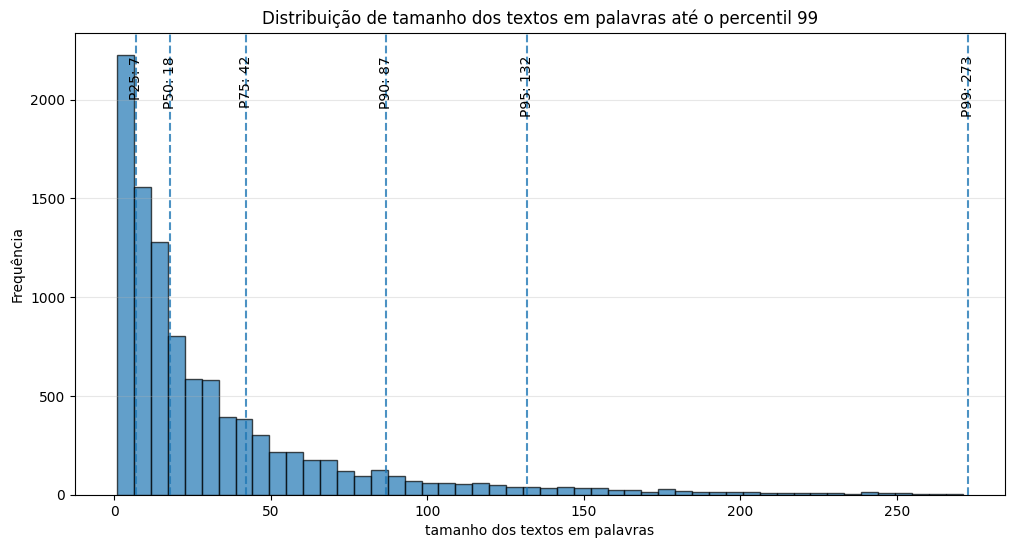

In [17]:
plotar_histograma_com_percentis(
    df_clean["length"],
    nome="tamanho dos textos em palavras",
    limite_percentil=0.99,
    percentis_marcados=[0.25, 0.50, 0.75, 0.90, 0.95, 0.99],
    bins=50,
    usar_milhoes=False,
    casas_decimais=0
)


Podemos observar pelo gráfico que o percentil P90 = 87 representa a quantidade de palavras que 90% dos textos das amostras possuem. Entendemos que para nossa amostra, esse percentil é adequado para o exercício. 

In [18]:
MAX_LENGTH = int(df_clean["length"].quantile(0.90))

print(MAX_LENGTH)

87


##### Codificando classes categóricas e definindo conjuntos X e y

In [19]:
X = df['Comment'].to_numpy()
y = df['Topic'].map({'Biology': 0, 'Chemistry': 1, 'Physics': 2})

X, y

(array(['Not everyone has a scientific mind. Many people are pleased with aesthetics. It makes them no better or worse. \\n\\nThe aesthetics can draw some in to investigate further. This is why science experiments for children are flashy and have abundant product.',
        'You\'re missing the point of the question.  It\'s not "can you measure the velocity of the bullet".  Obviously, you can, by measuring the shift.\\n\\nThe question is whether the observer sees it as a lightspeed weapon.  Which they do.  They see the bullet leave the gun 10 ls away (10 seconds after it actually does), and hit them 10 seconds later (total travel time of 20 seconds).\\n\\nFrom their perspective, they watched it travel 10ls in 10 seconds.\\n\\nI notice you\'ve stopped responding to the other string where we\'ve shown you can\'t do basic math.  Any particular reason?',
        'Russian? Use a trained bear 🐻', ...,
        "Fun biology fact:\\n\\nUnderstanding of homeostasis was essentially pioneered by a

### **2º Passo:**
<font size=3>

- Defina o objeto da vetorização dos dados textuais com a função [`TextVectorization`](https://keras.io/api/layers/preprocessing_layers/text/text_vectorization/):
    - Faça operações *regex* customizadas, caso seja necessário.
    - Defina o tamanho do vocabulário (`vocab_size`), o tamanho da entrada/janela do modelo (`max_len`), e a dimensão do vetor *embedding* (`embed_dim`);
    - Iremos realizar a vetorização (inexação) dentro da rede neural, ou seja, o objeto da vetorização irá processar os dados após a camada `layers.Input()`.
    <br>

- Divida os dados em treninamento (90%) e teste (10%) com a função [`train_test_split`](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.train_test_split.html) para estratificação. Os dados de validação serão divididos na função `model.fit()`.

- Identifique a proporção das classes a fim de **penalizar a função de perda** de acordo com a seguinte formulação:
    $$
        \text{Peso} = \frac{N_{total}}{N_{classes}\times \text{Contagem}_{classe}} \, ,
    $$
  onde função [`compute_class_weight`](https://scikit-learn.org/stable/modules/generated/sklearn.utils.class_weight.compute_class_weight.html) realiza esse cálculo. **A ideia é obter um dicionário da classe numérica relacionado ao peso**, que será utilizado durante o treinamento do modelo;

- Realize a transformação da variável alvo.


### Resolução item 2

#### Definindo `VOCAB_SIZE` e `MAX_LENGTH`

Definimos o valor de `MAX_LENGTH` no item anterior, `MAX_LENGTH = 87`

In [20]:
# Conta todas as ocorrências de palavras no dataset pré-processado
token_counts = Counter(
    token
    for comment in df_clean["Comment"]
    for token in comment.split()
)

# Ordena os tokens do mais frequente para o menos frequente
frequencias_ordenadas = sorted(token_counts.values(), reverse=True)

total_ocorrencias = sum(frequencias_ordenadas)
total_tokens_unicos = len(frequencias_ordenadas)

print(f"Total de ocorrências de palavras: {br_number(total_ocorrencias)}")
print(f"Quantidade de palavras distintas: {br_number(total_tokens_unicos)}")

Total de ocorrências de palavras: 372.954
Quantidade de palavras distintas: 21.229


In [21]:
vocab_sizes = [
     1_000,
     2_000,
     5_000,
    10_000,
    15_000,
    20_000,
    25_000
]

In [22]:
resultados_vocabulario = []

for vocab_size in vocab_sizes:
    tamanho_efetivo = min(vocab_size, total_tokens_unicos)

    ocorrencias_cobertas = sum(frequencias_ordenadas[:tamanho_efetivo])
    ocorrencias_oov = total_ocorrencias - ocorrencias_cobertas

    resultados_vocabulario.append({
        "VOCAB_SIZE": vocab_size,
        "palavras incluídas": tamanho_efetivo,
        "ocorrências cobertas": ocorrencias_cobertas,
        "cobertura (%)": ocorrencias_cobertas / total_ocorrencias * 100,
        "ocorrências OOV": ocorrencias_oov,
        "OOV (%)": ocorrencias_oov / total_ocorrencias * 100
    })

df_vocabulario = pd.DataFrame(resultados_vocabulario)

df_vocabulario.style.format({
    "VOCAB_SIZE": "{:,.0f}",
    "palavras incluídas": "{:,.0f}",
    "ocorrências cobertas": "{:,.0f}",
    "cobertura (%)": "{:.2f}",
    "ocorrências OOV": "{:,.0f}",
    "OOV (%)": "{:.2f}"
})

,VOCAB_SIZE,palavras incluídas,ocorrências cobertas,cobertura (%),ocorrências OOV,OOV (%)
0,"1,000","1,000","285,253",76.48,"87,701",23.52
1,"2,000","2,000","313,637",84.10,"59,317",15.90
2,"5,000","5,000","343,939",92.22,"29,015",7.78
3,"10,000","10,000","359,875",96.49,"13,079",3.51
4,"15,000","15,000","366,725",98.33,"6,229",1.67
5,"20,000","20,000","371,725",99.67,"1,229",0.33
6,"25,000","21,229","372,954",100.00,0,0.00


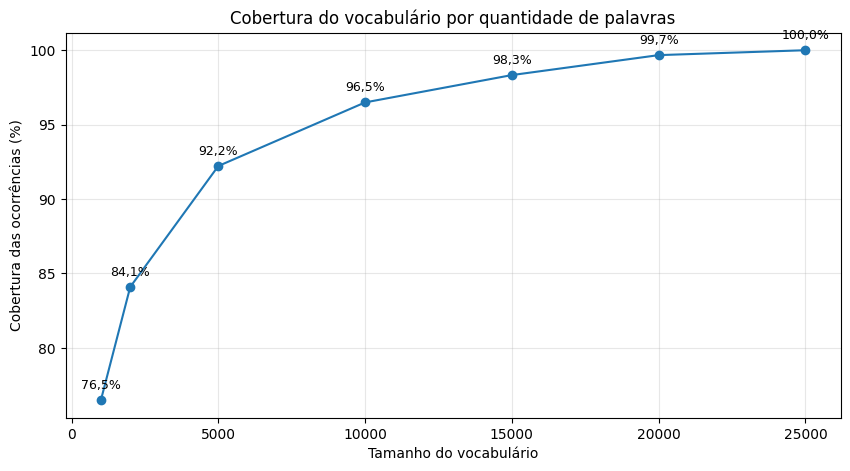

In [23]:
def plotar_cobertura_vocabulario():
    plt.figure(figsize=(10, 5))

    plt.plot(
        df_vocabulario["VOCAB_SIZE"],
        df_vocabulario["cobertura (%)"],
        marker="o"
    )

    for x, y in zip(
        df_vocabulario["VOCAB_SIZE"],
        df_vocabulario["cobertura (%)"]
    ):
        plt.annotate(
            f"{y:.1f}%".replace(".", ","),
            xy=(x, y),
            xytext=(0, 8),
            textcoords="offset points",
            ha="center",
            fontsize=9
        )

    plt.title("Cobertura do vocabulário por quantidade de palavras")
    plt.xlabel("Tamanho do vocabulário")
    plt.ylabel("Cobertura das ocorrências (%)")
    plt.grid(True, alpha=0.3)

    plt.show()

plotar_cobertura_vocabulario()

Pelo gráfico, podemos observar que para um vocabulário de 15.000 palavras, a cobertura é de 98,3%, o que é um valor bastante alto. Vamos definir então o vocabulário com 15.000 palavras.

In [24]:
VOCAB_SIZE = 15_000

#### Definindo `TextVectorization` e separando conjuntos train e test.

In [25]:
vectorizer = layers.TextVectorization(
    name="TextVectorizer",
    max_tokens=VOCAB_SIZE,
    output_sequence_length=MAX_LENGTH,
    standardize=Preprocessor,
    output_mode="int",
)

X_train, X_test, y_train, y_test = train_test_split(
  X,
  y,
  test_size=0.1,
  random_state=RANDOM_STATE,
  stratify=y
)

vectorizer.adapt(X_train)

print(f"Tamanho efetivo do vocabulário: {vectorizer.vocabulary_size()}")

Tamanho efetivo do vocabulário: 15000


Verificamos que a estratificação manteve a distribuição das classes

In [26]:
def comparar_distribuicao_classes(
    y_total,
    y_treino,
    y_avaliacao,
    nome_treino="Treino",
    nome_avaliacao="Teste"
):
    distribuicao_classes = pd.DataFrame({
        "Total - qtd": y_total.value_counts().sort_index(),
        "Total - %": y_total.value_counts(normalize=True).sort_index() * 100,
        f"{nome_treino} - qtd": y_treino.value_counts().sort_index(),
        f"{nome_treino} - %": y_treino.value_counts(normalize=True).sort_index() * 100,
        f"{nome_avaliacao} - qtd": y_avaliacao.value_counts().sort_index(),
        f"{nome_avaliacao} - %": y_avaliacao.value_counts(normalize=True).sort_index() * 100
    })

    distribuicao_classes.index.name = "Classe"

    return distribuicao_classes.style.format({
        "Total - qtd": "{:,.0f}",
        "Total - %": "{:.2f}%",
        f"{nome_treino} - qtd": "{:,.0f}",
        f"{nome_treino} - %": "{:.2f}%",
        f"{nome_avaliacao} - qtd": "{:,.0f}",
        f"{nome_avaliacao} - %": "{:.2f}%"
    })

In [27]:
comparar_distribuicao_classes(
    y_total=y,
    y_treino=y_train,
    y_avaliacao=y_test
)

,Total - qtd,Total - %,Treino - qtd,Treino - %,Teste - qtd,Teste - %
Classe,,,,,,
0,"4,202",41.01%,"3,782",41.01%,420,40.98%
1,"3,410",33.28%,"3,069",33.28%,341,33.27%
2,"2,635",25.71%,"2,371",25.71%,264,25.76%


#### Definindo `computed_class_weights` e transformando a variável alvo

A função `compute_class_weights` retorna o array com os pesos das classes. Já a variável alvo `y` já foi transformada nos passos anteriores.

In [28]:
computed_class_weights = compute_class_weight(class_weight="balanced", classes=np.unique(y), y=y)

computed_class_weights

array([0.81286689, 1.00166178, 1.29626818])

### **3º Passo:**
<font size=3>

- Desenvolva a **arquitetura neural** com base nas camadas recorrentes:
    - [`SimpleRNN`](https://keras.io/api/layers/recurrent_layers/simple_rnn/);
    - [`LSTM`](https://keras.io/api/layers/recurrent_layers/lstm/);
    - [`GRU`](https://keras.io/api/layers/recurrent_layers/gru/);
    - [`Bidirectional`](https://keras.io/api/layers/recurrent_layers/bidirectional/).
    <br>

- Compile o modelo com um otimizador ([`SGR`](https://keras.io/api/optimizers/sgd/), [`RMSprop`](https://keras.io/api/optimizers/rmsprop/), [`Adam`](https://keras.io/api/optimizers/adam/));
- Defina a função de perda e métrica de acordo com a natureza do problema.
  

#### Resolução Item 3

Ao invés de executar e treinar alguns poucos modelos, vamos adotar uma abordagem mais sistematizada para definição do modelo. Trabalharemos com RandomSearch e GridSearch e trataremos alguns hiperparâmetros do modelo com essas buscas. Trataremos a própria arquitetura do modelo como um hiperparâmetro no espaço de buscas. Para isso, vamos utilizar Keras Tuner e os seguintes hiperparâmetros:

- embed_dim = [100]
- recurrent_type = ["lstm", "gru"]
- recurrent_units = [32, 64]
- bidirectional = [ true, false ]
- dense_units = [32]
- dropout_rate = [0.2, 0.4]
- optimizer = ["adam", "rmsprop"]
- learning_rate = [1e-3, 1e-4]

Isso nos dá um espaço de busca com 64 combinações possíveis. Vamos utilizar early stopping com patience = 3 e 48 execuções. Isso nos dará uma cobertura de 75% do espaço. Lembrando que será uma busca preliminar, pois vamos analisar os resultados obtidos para definir uma segunda busca com as configurações mais promissoras posteriormente.

Mencionamos também que decidimos deliberadamente:

- Fixar embed_dim = 100: se necessario exploraremos outras opções na seguinte etapa de busca, por hora vamos explorar outros parametros.
- Descartar arquitetura SimpleRNN: como já estamos testando versões mais sofisticadas, optamos por descatar essa opção para diminuir o espaço de busca
- Descartar Otimizador SGD: esse otimizador se mostrou pouco promissor com redes relativamente mais simples em exercícios passados. Agora que temos uma RNN, acreditamos que podemos abrir mão dessa opção em favor de trabalhar um espaço de busca menor
- Descartar Learning Rate 1e-2: learning rate mais alto numa rede RNN, que por definição deve propagar gradientes por uma profundidade maior, tende a gerar treinamento mais instável.
- Descartar camada recorrente de tamanho 16: vamos preferir explorar as opções com tamanho 32 e 64 apenas para priorizar diminuição do espaço de busca
- Fixar a camada densa em tamanho 32: acreditamos que a característica do problema a ser resolvido não deveria exigir uma rede densa mais sofisticada
- Testar somente com dropout 0.2 e 0.4, descartando a opção com dropout = 0.0: por trabalhar redes recorrentes com profundidade relativamente alta, acreditamos que aplicar ao menos um dropout de 0.2 é necessaário para evitar overfitting.

Essas decisões nos permitem diminuir o espaço de busca, eliminando de cara opções pouco promissoras. E nos permite ao mesmo tempo cobrir um maior espaço de busca.

##### Definição do modelo

A seguir implementamos a função que vai criar os modelos de nossa primeira busca.

In [ ]:
def build_model(hp, num_classes):

    # embed_dim = hp.Choice(
    #     "embed_dim",
    #     values=[50, 100, 200]
    # )
    embed_dim = 100
    recurrent_type = hp.Choice(
        "recurrent_type",
        values=[
            # "simple_rnn", 
            "lstm", 
            "gru"
        ]
    )

    recurrent_units = hp.Choice(
        "recurrent_units",
        values=[
            # 16,
            32, 
            64
        ]
    )

    bidirectional = hp.Boolean(
        "bidirectional"
    )

    # dense_units = hp.Choice(
    #     "dense_units",
    #     values=[32]
    # )
    dense_units = 32

    dropout_rate = hp.Choice(
        "dropout_rate",
        values=[0.2, 0.4]
    )

    optimizer_name = hp.Choice(
        "optimizer",
        values=[
            "adam", 
            "rmsprop", 
            # "sgd"
        ]
    )

    learning_rate = hp.Choice(
        "learning_rate",
        values=[
            # 1e-2, 
            1e-3, 
            1e-4
        ]
    )

    x_in = layers.Input(
        shape=(1,),
        dtype=tf.string,
        name="review"
    )

    x = vectorizer(x_in)

    x = layers.Embedding(
        input_dim=vectorizer.vocabulary_size(),
        output_dim=embed_dim,
        mask_zero=True,
        name="embedding"
    )(x)

    if recurrent_type == "simple_rnn":
        recurrent_layer = layers.SimpleRNN(
            units=recurrent_units,
            name="simple_rnn"
        )
    elif recurrent_type == "lstm":
        recurrent_layer = layers.LSTM(
            units=recurrent_units,
            name="lstm"
        )
    else:
        recurrent_layer = layers.GRU(
            units=recurrent_units,
            name="gru"
        )

    if bidirectional:
        x = layers.Bidirectional(
            recurrent_layer,
            name=f"bidirectional_{recurrent_type}"
        )(x)
    else:
        x = recurrent_layer(x)

    x = layers.Dense(
        units=dense_units,
        activation="relu",
        name="hidden"
    )(x)

    x = layers.Dropout(
        rate=dropout_rate,
        name="dropout"
    )(x)

    y_out = layers.Dense(
        units=num_classes,
        activation="softmax",
        name="output"
    )(x)

    model = tf.keras.Model(
        inputs=x_in,
        outputs=y_out
    )

    if optimizer_name == "adam":
        optimizer = tf.keras.optimizers.Adam(
            learning_rate=learning_rate
        )
    elif optimizer_name == "rmsprop":
        optimizer = tf.keras.optimizers.RMSprop(
            learning_rate=learning_rate
        )
    else:
        optimizer = tf.keras.optimizers.SGD(
            learning_rate=learning_rate
        )

    model.compile(
        optimizer=optimizer,
        loss="sparse_categorical_crossentropy",
        metrics=[
            tf.keras.metrics.SparseCategoricalAccuracy(
                name="accuracy"
            )
        ]
    )

    return model


##### Customização do RandomSearch

E também aproveitamos para customizar o RandomSearch para armazenar histórico de acurácia e loss ao longo das épocas

In [ ]:
class RandomSearchWithHistory(kt.RandomSearch):

    def run_trial(self, trial, *args, **kwargs):
        trial_dir = Path(
            self.get_trial_dir(trial.trial_id)
        )

        trial_dir.mkdir(
            parents=True,
            exist_ok=True
        )

        callbacks = list(
            kwargs.pop("callbacks", [])
        )

        callbacks.append(
            tf.keras.callbacks.CSVLogger(
                filename=str(trial_dir / "history.csv"),
                append=False
            )
        )

        kwargs["callbacks"] = callbacks

        return super().run_trial(
            trial,
            *args,
            **kwargs
        )

##### Instanciação do RandomSearch

Por fim, finalizamos a seção instanciando o objeto que vai executar a busca.

In [ ]:
MAX_TRIALS = 48
NUM_CLASSES = len(np.unique(y_train))

RESULTS_DIR = Path("./results-atividade3")
PROJECT_NAME = "search-01"
PROJECT_DIR = RESULTS_DIR / PROJECT_NAME

ORACLE_FILE = PROJECT_DIR / "oracle.json"
TENSORBOARD_DIR = PROJECT_DIR / "tensorboard"

tuner = RandomSearchWithHistory(
    hypermodel=lambda hp: build_model(
        hp,
        num_classes=NUM_CLASSES
    ),
    objective="val_accuracy",
    max_trials=MAX_TRIALS,
    executions_per_trial=1,
    seed=RANDOM_STATE,
    overwrite=False,
    directory=str(RESULTS_DIR),
    project_name=PROJECT_NAME
)

tuner.search_space_summary()

Search space summary
Default search space size: 6
recurrent_type (Choice)
{'default': 'lstm', 'conditions': [], 'values': ['lstm', 'gru'], 'ordered': False}
recurrent_units (Choice)
{'default': 32, 'conditions': [], 'values': [32, 64], 'ordered': True}
bidirectional (Boolean)
{'default': False, 'conditions': []}
dropout_rate (Choice)
{'default': 0.2, 'conditions': [], 'values': [0.2, 0.4], 'ordered': True}
optimizer (Choice)
{'default': 'adam', 'conditions': [], 'values': ['adam', 'rmsprop'], 'ordered': False}
learning_rate (Choice)
{'default': 0.001, 'conditions': [], 'values': [0.001, 0.0001], 'ordered': True}


### **4º Passo:**
<font size=3>

- Treine o modelo com o método `.fit()`, definindo as variáveis:
    - `validation_split`: porcentagem de dados para validação;
    - `epochs`: número de épocas para o treinamento;
    - `batch_size`: tamanho do lote da amostragem dos dados de entrada;
    - `class_weight`: dicionário de classes relacionadas aos pesos de penalização.
      

#### Resolução Item 4

##### Divisão dos conjuntos de treino e validação

Vamos ter que fazer a separação do conjunto de treino e validação pois a função validation_split não vai manter a estratificação das classes. Então vamos aplicar novamente train_test_split, dessa ver sobre (X_train, y_train), com 20% para validação.

In [32]:
X_search_train, X_search_val, y_search_train, y_search_val = (
    train_test_split(
        X_train,
        y_train,
        test_size=0.2,
        random_state=RANDOM_STATE,
        stratify=y_train
    )
)


E vamos comparar com a distribuição original ...

In [33]:

comparar_distribuicao_classes(
    y_total=y,
    y_treino=y_train,
    y_avaliacao=y_test
)


,Total - qtd,Total - %,Treino - qtd,Treino - %,Teste - qtd,Teste - %
Classe,,,,,,
0,"4,202",41.01%,"3,782",41.01%,420,40.98%
1,"3,410",33.28%,"3,069",33.28%,341,33.27%
2,"2,635",25.71%,"2,371",25.71%,264,25.76%


... para garantir que os conjuntos de treino, validação e teste mantém a estratificação das classes.

In [34]:

comparar_distribuicao_classes(
    y_total=y_train,
    y_treino=y_search_train,
    y_avaliacao=y_search_val,
    nome_treino="Treino da busca",
    nome_avaliacao="Validação da busca"
)

,Total - qtd,Total - %,Treino da busca - qtd,Treino da busca - %,Validação da busca - qtd,Validação da busca - %
Classe,,,,,,
0,"3,782",41.01%,"3,025",41.01%,757,41.03%
1,"3,069",33.28%,"2,455",33.28%,614,33.28%
2,"2,371",25.71%,"1,897",25.72%,474,25.69%


##### Executando a busca

Somente executamos a busca se os resultados já não foram gravados no disco ainda pois o tuner foi criado com o parâmetro overwrite=False. Utilizaremos 20 épocas e early stopping sobre val_loss com patience = 3.

In [ ]:
tuner.search(
    X_search_train,
    y_search_train,
    validation_data=(
        X_search_val,
        y_search_val
    ),
    epochs=20,
    batch_size=64,
    callbacks=[
        tf.keras.callbacks.EarlyStopping(
            monitor="val_loss",
            patience=3,
            restore_best_weights=True
        )
    ]
)

Trial 48 Complete [00h 02m 50s]
val_accuracy: 0.41084009408950806

Best val_accuracy So Far: 0.7436314225196838
Total elapsed time: 04h 01m 43s


##### Resumo dos resultados da busca inicial

In [36]:
resultados_trials = []

for trial in tuner.oracle.trials.values():
    resultados_trials.append({
        "trial_id": trial.trial_id,
        "status": trial.status,
        "val_accuracy": trial.score,
        "melhor_epoca": trial.best_step + 1 if trial.best_step is not None else None,
        **trial.hyperparameters.values
    })

df_trials = (
    pd.DataFrame(resultados_trials)
    .sort_values("val_accuracy", ascending=False)
    .reset_index(drop=True)
)

df_trials

,trial_id,status,val_accuracy,melhor_epoca,recurrent_type,recurrent_units,bidirectional,dropout_rate,optimizer,learning_rate
0,33,COMPLETED,0.743631,12,lstm,64,True,0.2,adam,0.0010
1,21,COMPLETED,0.721951,10,gru,32,True,0.4,adam,0.0010
2,11,COMPLETED,0.720325,14,lstm,32,True,0.4,adam,0.0010
3,20,COMPLETED,0.717615,17,lstm,64,False,0.2,adam,0.0010
4,07,COMPLETED,0.717073,9,gru,32,True,0.2,adam,0.0010
5,05,COMPLETED,0.709485,16,lstm,32,True,0.2,adam,0.0001
6,23,COMPLETED,0.657453,11,lstm,64,False,0.2,adam,0.0001
7,42,COMPLETED,0.652575,20,lstm,64,False,0.4,adam,0.0001
8,17,COMPLETED,0.649323,13,lstm,64,False,0.4,adam,0.0010
9,34,COMPLETED,0.642818,20,gru,64,False,0.4,adam,0.0001


Com base no resumo dos resultados podemos observar 6 configurações com desempenho de acurácia superior a 70%. Observa-se também uma quantidade de configurações significativa com desempenho próximo a 41% de acurácia. Esse desempenho é próximo ao desempenho de uma estratégia ingênua de prever sempre a classe de maior representatividade, o que indica que tais configurações não foram capazes de aprender algo útil. Entretanto, todas essas configurações utilizaram o otimizador `rmsprop`. Isso sugere que nesses treinamentos talvez ele tenha deixando de avançar nos gradientes (uma característica já sabida desse otimizador).

##### Definindo a segunda busca

Tendo em vista o desempenho dos top2 (lstm(64), gru(32)) do random search anterior, acreditamos ser interessante:

- Fixar o otimizador como Adam
- Fixar o Learning Rate em 1e-3
- Fixar a bidirecionalidade ativada
- Manter dropout rate explorando os valores [0.2, 0.4]
- Variar embed_dim = [100, 150, 200]
- Variar dense_units = [32, 64]

Isso nos vai permitir explorar outros parâmetros que haviam sido fixados, mas num conjunto menor de possibilidades, próximas aos melhores valores que obtivemos.

Também queremos explorar o aumento do tamanho do embedding e da camada densa para avaliar se representações mais complexas podem ajudar a melhorar o desempenho de acurácia do modelo.
Vamos fazer isso dessa vez utilizando um grid search, já que o espaço ficou bem menor agora. Também vamos aumentar o patience do early stopping para 5 e o limite de épocas para 30, para o caso dessas novas combinações de parametros apresentarem convergencia mais lenta.

A seguir definimos as variáveis para essa nova execução.

In [57]:
RESULTS_DIR = Path("./results-atividade3")
PROJECT_NAME = "search-02-grid"

PROJECT_DIR = RESULTS_DIR / PROJECT_NAME
TENSORBOARD_DIR = PROJECT_DIR / "tensorboard"
ORACLE_FILE = PROJECT_DIR / "oracle.json"

##### Criação de especialização do GridSearch

Definimos uma extensão do GridSearch para guardar os históricos necessários para gerar as curvas de loss e acurácia:

In [58]:
class GridSearchWithHistory(kt.GridSearch):

    def run_trial(self, trial, *args, **kwargs):
        trial_dir = Path(
            self.get_trial_dir(trial.trial_id)
        )

        trial_dir.mkdir(
            parents=True,
            exist_ok=True
        )

        callbacks = list(
            kwargs.pop("callbacks", [])
        )

        callbacks.append(
            tf.keras.callbacks.CSVLogger(
                filename=str(
                    trial_dir / "history.csv"
                ),
                append=False
            )
        )

        kwargs["callbacks"] = callbacks

        return super().run_trial(
            trial,
            *args,
            **kwargs
        )

##### Criação da função de criação do modelo

E definimos também nossa função de criação do modelo.

In [64]:
def build_model_search_02(hp, num_classes):

    architecture = hp.Choice(
        "architecture",
        values=[
            "lstm_64_bi",
            "gru_32_bi"
        ]
    )

    embed_dim = hp.Choice(
        "embed_dim",
        values=[100, 150, 200]
    )

    dense_units = hp.Choice(
        "dense_units",
        values=[32, 64]
    )

    dropout_rate = hp.Choice(
        "dropout_rate",
        values=[0.2, 0.4]
    )

    learning_rate = 1e-3

    x_in = layers.Input(
        shape=(1,),
        dtype=tf.string,
        name="text"
    )

    x = vectorizer(x_in)

    x = layers.Embedding(
        input_dim=vectorizer.vocabulary_size(),
        output_dim=embed_dim,
        mask_zero=True,
        name="embedding"
    )(x)

    if architecture == "lstm_64_bi":
        x = layers.Bidirectional(
            layers.LSTM(
                units=64,
                name="lstm"
            ),
            name="bidirectional_lstm"
        )(x)

    else:
        x = layers.Bidirectional(
            layers.GRU(
                units=32,
                name="gru"
            ),
            name="bidirectional_gru"
        )(x)

    x = layers.Dense(
        units=dense_units,
        activation="relu",
        name="hidden"
    )(x)

    x = layers.Dropout(
        rate=dropout_rate,
        name="dropout"
    )(x)

    y_out = layers.Dense(
        units=num_classes,
        activation="softmax",
        name="output"
    )(x)

    model = tf.keras.Model(
        inputs=x_in,
        outputs=y_out
    )

    model.compile(
        optimizer=tf.keras.optimizers.Adam(
            learning_rate=learning_rate
        ),
        loss="sparse_categorical_crossentropy",
        metrics=[
            tf.keras.metrics.SparseCategoricalAccuracy(
                name="accuracy"
            )
        ]
    )

    return model

##### Instanciando o GridSearch

Por fim instanciamos nosso grid search `tuner_search_02`

In [67]:
tuner_search_02 = GridSearchWithHistory(
    hypermodel=lambda hp: build_model_search_02(
        hp,
        num_classes=NUM_CLASSES
    ),
    objective="val_accuracy",
    overwrite=False,
    directory=str(RESULTS_DIR),
    project_name=PROJECT_NAME
)

tuner_search_02.search_space_summary()

Search space summary
Default search space size: 4
architecture (Choice)
{'default': 'lstm_64_bi', 'conditions': [], 'values': ['lstm_64_bi', 'gru_32_bi'], 'ordered': False}
embed_dim (Choice)
{'default': 100, 'conditions': [], 'values': [100, 150, 200], 'ordered': True}
dense_units (Choice)
{'default': 32, 'conditions': [], 'values': [32, 64], 'ordered': True}
dropout_rate (Choice)
{'default': 0.2, 'conditions': [], 'values': [0.2, 0.4], 'ordered': True}


##### Executando o GridSearch

E executamos a busca.

In [68]:
tuner_search_02.search(
    X_search_train,
    y_search_train,
    validation_data=(
        X_search_val,
        y_search_val
    ),
    epochs=30,
    batch_size=64,
    callbacks=[
        tf.keras.callbacks.EarlyStopping(
            monitor="val_loss",
            patience=5,
            restore_best_weights=True
        )
    ]
)

Trial 24 Complete [00h 02m 02s]
val_accuracy: 0.7306233048439026

Best val_accuracy So Far: 0.7457994818687439
Total elapsed time: 00h 50m 50s


In [70]:
TRIALS_FILE = PROJECT_DIR / "trials.csv"

if not TRIALS_FILE.exists():
    resultados_trials_02 = []

    for trial in tuner_search_02.oracle.trials.values():
        resultados_trials_02.append({
            "trial_id": trial.trial_id,
            "status": trial.status,
            "val_accuracy": trial.score,
            "melhor_epoca": (
                trial.best_step + 1
                if trial.best_step is not None
                else None
            ),
            **trial.hyperparameters.values
        })

    df_trials_02 = (
        pd.DataFrame(resultados_trials_02)
        .sort_values(
            "val_accuracy",
            ascending=False,
            na_position="last"
        )
        .reset_index(drop=True)
    )

    df_trials_02.to_csv(
        TRIALS_FILE,
        index=False
    )
else:
    df_trials_02 = pd.read_csv(
        TRIALS_FILE,
        dtype={
            "trial_id": str
        }
    )

df_trials_02

,trial_id,status,val_accuracy,melhor_epoca,architecture,embed_dim,dense_units,dropout_rate
0,0005,COMPLETED,0.745799,11,lstm_64_bi,150,32,0.4
1,0009,COMPLETED,0.737127,11,lstm_64_bi,200,32,0.4
2,0007,COMPLETED,0.736585,14,lstm_64_bi,150,64,0.4
3,0017,COMPLETED,0.736043,12,gru_32_bi,150,32,0.4
4,0008,COMPLETED,0.736043,11,lstm_64_bi,200,32,0.2
5,0012,COMPLETED,0.733875,12,gru_32_bi,100,32,0.2
6,0002,COMPLETED,0.733333,16,lstm_64_bi,100,64,0.2
7,0021,COMPLETED,0.731165,14,gru_32_bi,200,32,0.4
8,0006,COMPLETED,0.731165,12,lstm_64_bi,150,64,0.2
9,0019,COMPLETED,0.731165,13,gru_32_bi,150,64,0.4


##### Analisando os resultados

Primeiro vamos criar uma função para gerar o grafico com o historico por épocas da acurácia e da função de perda. 

In [130]:
def plotar_historico_melhores_modelos(
    tuner,
    top_n=3,
    epochs=None
):
    """
    Carrega e plota os históricos salvos durante a execução do tuner.

    Para cada modelo, gera dois gráficos lado a lado:
    - acurácia de treino e validação;
    - loss de treino e validação.

    A época com maior val_accuracy é marcada por uma linha vertical pontilhada.

    Não realiza novo treinamento.

    Parameters
    ----------
    tuner : keras_tuner.Tuner
        Tuner previamente executado ou carregado com overwrite=False.

    top_n : int
        Quantidade de melhores trials que serão exibidos.

    epochs : int ou None
        Limite máximo do eixo x.
        Caso seja None, utiliza a maior quantidade de épocas registrada
        entre os trials selecionados.

    Returns
    -------
    dict
        Históricos, hiperparâmetros e métricas dos trials selecionados.
    """
    melhores_trials = tuner.oracle.get_best_trials(
        num_trials=top_n
    )

    historicos = {}

    # Carrega os históricos antes de criar os gráficos para definir
    # uma escala comum no eixo x.
    for trial in melhores_trials:
        trial_id = str(trial.trial_id)

        trial_dir = Path(
            tuner.get_trial_dir(trial_id)
        )

        history_file = trial_dir / "history.csv"

        if not history_file.exists():
            raise FileNotFoundError(
                f"Histórico não encontrado para o trial {trial_id}: "
                f"{history_file}"
            )

        history_df = pd.read_csv(
            history_file
        )

        # CSVLogger normalmente salva uma coluna epoch iniciando em 0.
        # Criamos uma coluna iniciando em 1 apenas para exibição.
        if "epoch" in history_df.columns:
            history_df["epoca"] = (
                history_df["epoch"] + 1
            )
        else:
            history_df["epoca"] = range(
                1,
                len(history_df) + 1
            )

        melhor_indice = (
            history_df["val_accuracy"]
            .idxmax()
        )

        melhor_epoca = int(
            history_df.loc[
                melhor_indice,
                "epoca"
            ]
        )

        melhor_val_accuracy = float(
            history_df.loc[
                melhor_indice,
                "val_accuracy"
            ]
        )

        historicos[trial_id] = {
            "historico": history_df,
            "hiperparametros": (
                trial.hyperparameters.values
            ),
            "melhor_epoca": melhor_epoca,
            "melhor_val_accuracy": melhor_val_accuracy,
            "trial_dir": trial_dir
        }

    if epochs is None:
        epochs = max(
            len(resultado["historico"])
            for resultado in historicos.values()
        )

    fig, axes = plt.subplots(
        nrows=len(historicos),
        ncols=2,
        figsize=(16, 5 * len(historicos)),
        squeeze=False
    )

    for indice, (
        trial_id,
        resultado
    ) in enumerate(historicos.items()):

        history_df = resultado["historico"]
        hp = resultado["hiperparametros"]

        epocas = history_df["epoca"]

        melhor_epoca = resultado["melhor_epoca"]
        melhor_val_accuracy = resultado[
            "melhor_val_accuracy"
        ]

        parametros = (
            f"Trial {trial_id} | "
            f"arquitetura={hp.get('architecture')} | "
            f"embedding={hp.get('embed_dim')} | "
            f"dense={hp.get('dense_units')} | "
            f"dropout={hp.get('dropout_rate'):.1f}"
        )

        ax_accuracy = axes[indice, 0]
        ax_loss = axes[indice, 1]

        # Gráfico de acurácia
        ax_accuracy.plot(
            epocas,
            history_df["accuracy"],
            label="Treino"
        )

        ax_accuracy.plot(
            epocas,
            history_df["val_accuracy"],
            label="Validação"
        )

        ax_accuracy.axvline(
            melhor_epoca,
            linestyle="--",
            linewidth=1.5,
            alpha=0.8,
            label=f"Melhor época: {melhor_epoca}"
        )

        ax_accuracy.scatter(
            melhor_epoca,
            melhor_val_accuracy,
            zorder=3
        )

        ax_accuracy.set_title(
            f"{parametros}\n"
            f"Evolução da acurácia | "
            f"melhor val_accuracy={melhor_val_accuracy:.4f}"
        )

        ax_accuracy.set_xlabel("Época")
        ax_accuracy.set_ylabel("Acurácia")
        ax_accuracy.set_xlim(1, epochs)
        ax_accuracy.grid(True, alpha=0.3)
        ax_accuracy.legend()

        # Gráfico de loss
        ax_loss.plot(
            epocas,
            history_df["loss"],
            label="Treino"
        )

        ax_loss.plot(
            epocas,
            history_df["val_loss"],
            label="Validação"
        )

        ax_loss.axvline(
            melhor_epoca,
            linestyle="--",
            linewidth=1.5,
            alpha=0.8,
            label=f"Melhor época: {melhor_epoca}"
        )

        ax_loss.set_title(
            f"{parametros}\n"
            f"Evolução da loss"
        )

        ax_loss.set_xlabel("Época")
        ax_loss.set_ylabel("Loss")
        ax_loss.set_xlim(1, epochs)
        ax_loss.grid(True, alpha=0.3)
        ax_loss.legend()

    plt.tight_layout()
    plt.show()

    return historicos

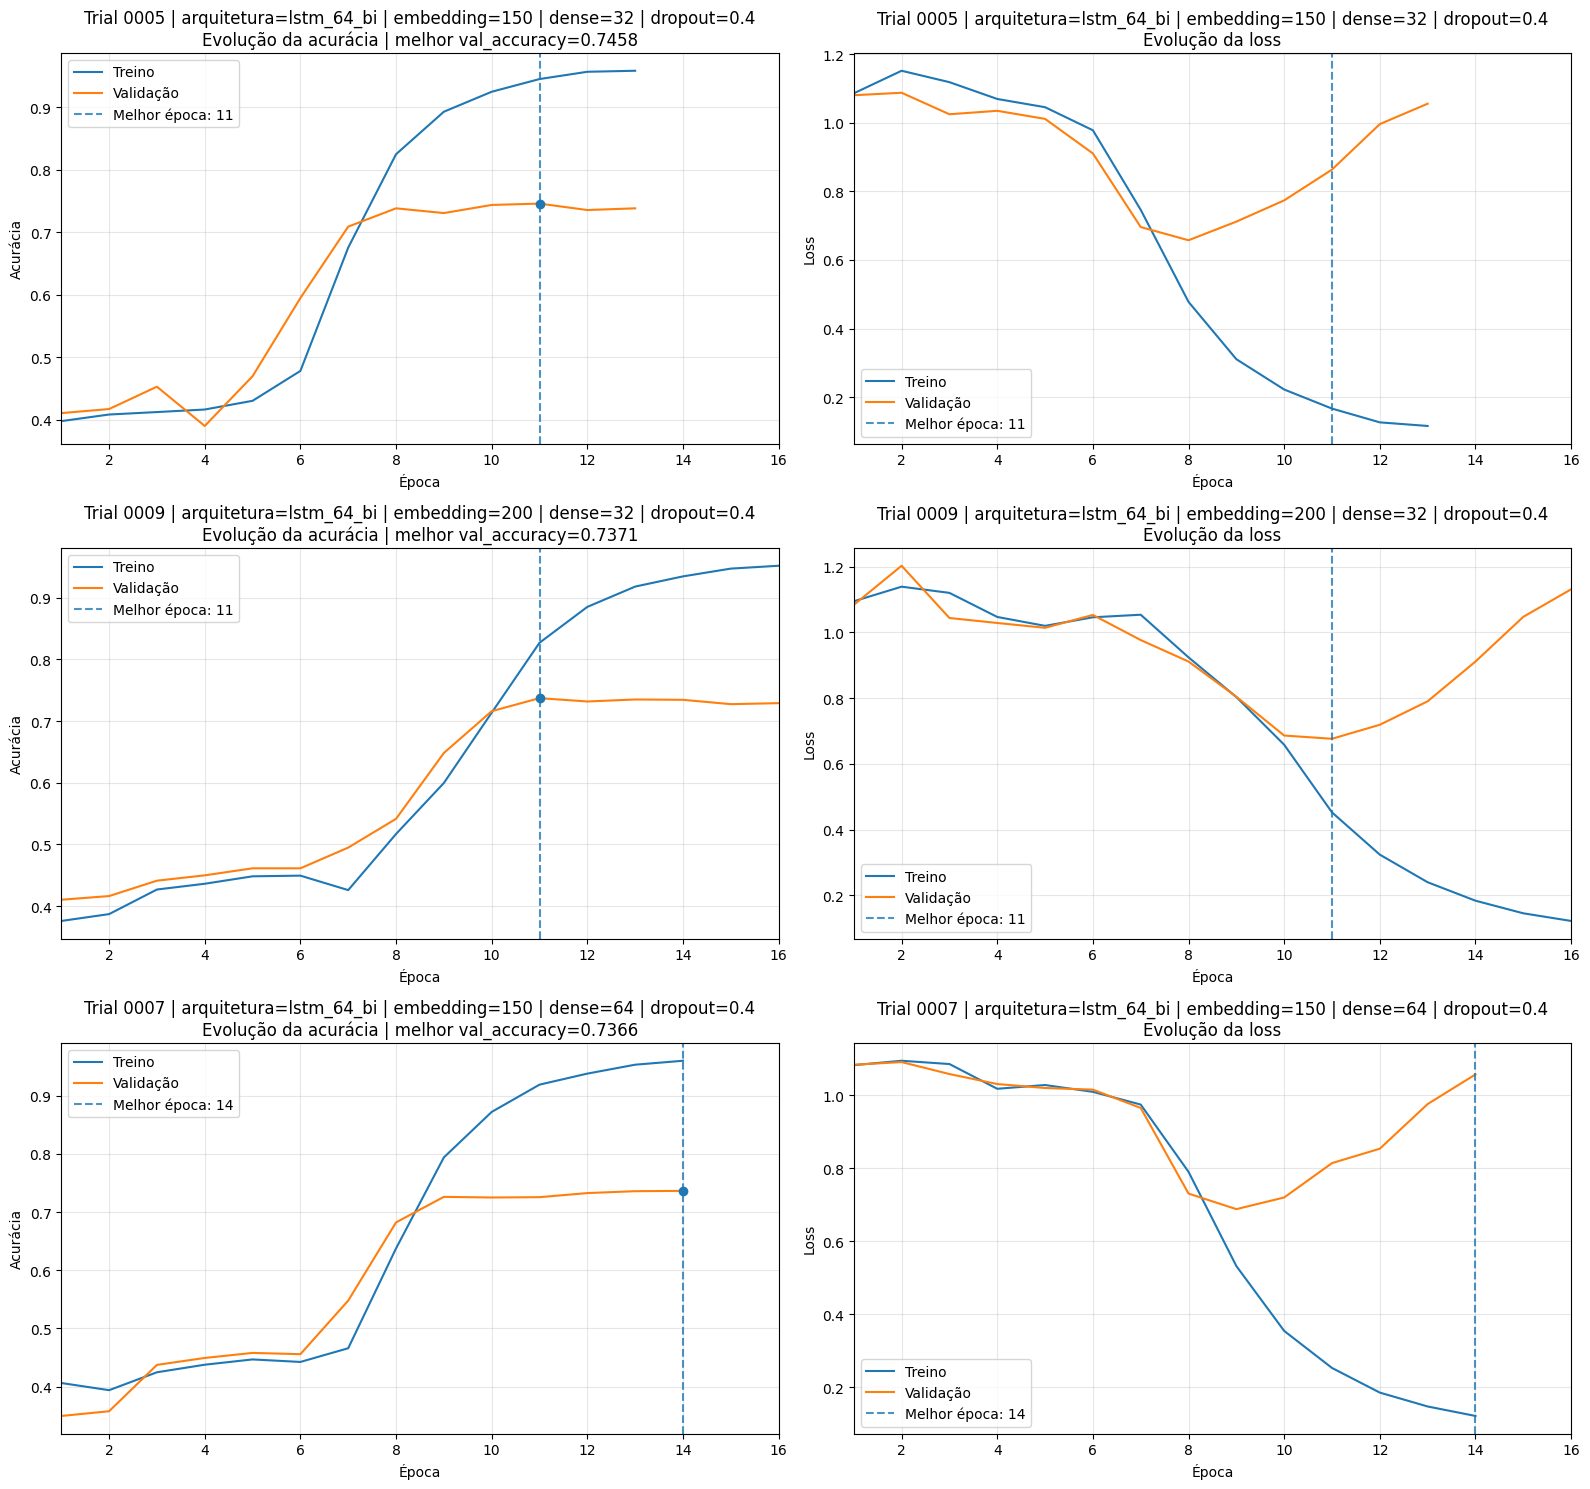

In [131]:
historicos_melhores_modelos = (
    plotar_historico_melhores_modelos(
        tuner=tuner_search_02,
        top_n=3
    )
)

A melhor configuração encontrada foi composta por uma camada `Embedding` com dimensão 150, seguida por uma camada `Bidirectional(LSTM)` com 64 unidades, uma camada densa com 32 neurônios e `dropout` de 0,4, alcançando `val_accuracy` de 0,7458 na época 11. A escolha desse modelo foi baseada tanto no maior desempenho de validação quanto na comparação com configurações próximas: o aumento do *embedding* para 200 não produziu melhoria, e a ampliação da camada densa para 64 unidades também não resultou em ganho de acurácia. As curvas de treinamento mostram que, após aproximadamente a oitava época, a acurácia de treino continua aumentando enquanto a *loss* de validação passa a crescer, indicando início de sobreajuste. Por esse motivo, foi selecionado o estado correspondente à melhor acurácia de validação, em vez da última época executada.

### **5º Passo:**
<font size=3>

- Quando definida uma boa arquitetura neural, faça o **treinamento final** do modelo com todos os dados de treinamento (sem validação).

#### Resolucao Item 5

A função a seguir instancia o modelo que escolhemos no passo 4.

In [76]:
def build_final_model(num_classes):

    x_in = layers.Input(
        shape=(1,),
        dtype=tf.string,
        name="text"
    )

    x = vectorizer(x_in)

    x = layers.Embedding(
        input_dim=vectorizer.vocabulary_size(),
        output_dim=150,
        mask_zero=True,
        name="embedding"
    )(x)

    x = layers.Bidirectional(
        layers.LSTM(
            units=64,
            name="lstm"
        ),
        name="bidirectional_lstm"
    )(x)

    x = layers.Dense(
        units=32,
        activation="relu",
        name="hidden"
    )(x)

    x = layers.Dropout(
        rate=0.4,
        name="dropout"
    )(x)

    y_out = layers.Dense(
        units=num_classes,
        activation="softmax",
        name="output"
    )(x)

    model = tf.keras.Model(
        inputs=x_in,
        outputs=y_out
    )

    model.compile(
        optimizer=tf.keras.optimizers.Adam(
            learning_rate=1e-3
        ),
        loss="sparse_categorical_crossentropy",
        metrics=[
            tf.keras.metrics.SparseCategoricalAccuracy(
                name="accuracy"
            )
        ]
    )

    return model

Definimos algumas variáveis para guardar o modelo treinado

In [80]:
FINAL_MODEL_DIR = RESULTS_DIR / "final-model"

MODEL_FILE = FINAL_MODEL_DIR / "model.keras"
HISTORY_FILE = FINAL_MODEL_DIR / "history.csv"

FINAL_MODEL_DIR.mkdir(
    parents=True,
    exist_ok=True
)

Limpamos sessão e executamos o treinamento utilizando o conjunto (X_train, y_train) completo. Caso o modelo já tenha sido treinado e salvo, carrega o modelo salvo do disco.

In [ ]:
tf.keras.backend.clear_session()
tf.keras.utils.set_random_seed(RANDOM_STATE)

if MODEL_FILE.exists():
    print(f"Carregando modelo existente: {MODEL_FILE}")

    final_model = tf.keras.models.load_model(
        MODEL_FILE
    )

    if HISTORY_FILE.exists():
        final_history_df = pd.read_csv(
            HISTORY_FILE
        )

        print(
            f"Histórico carregado: {HISTORY_FILE}"
        )
    else:
        final_history_df = None

        print(
            "Modelo carregado, mas o arquivo de histórico "
            "não foi encontrado."
        )

else:
    print("Modelo ainda não existe. Iniciando treinamento.")

    final_model = build_final_model(
        num_classes=NUM_CLASSES
    )

    final_history = final_model.fit(
        X_train,
        y_train,
        epochs=11,
        batch_size=64,
        shuffle=True,
        verbose=1
    )

Epoch 1/11
145/145 ━━━━━━━━━━━━━━━━━━━━ 13s 77ms/step - accuracy: 0.3959 - loss: 1.0870
Epoch 2/11
145/145 ━━━━━━━━━━━━━━━━━━━━ 10s 67ms/step - accuracy: 0.3761 - loss: 1.1590
Epoch 3/11
145/145 ━━━━━━━━━━━━━━━━━━━━ 10s 67ms/step - accuracy: 0.4003 - loss: 1.1119
Epoch 4/11
145/145 ━━━━━━━━━━━━━━━━━━━━ 10s 67ms/step - accuracy: 0.4112 - loss: 1.0864
Epoch 5/11
145/145 ━━━━━━━━━━━━━━━━━━━━ 10s 67ms/step - accuracy: 0.4366 - loss: 1.0378
Epoch 6/11
145/145 ━━━━━━━━━━━━━━━━━━━━ 10s 67ms/step - accuracy: 0.4509 - loss: 0.9978
Epoch 7/11
145/145 ━━━━━━━━━━━━━━━━━━━━ 10s 68ms/step - accuracy: 0.6684 - loss: 0.7549
Epoch 8/11
145/145 ━━━━━━━━━━━━━━━━━━━━ 10s 69ms/step - accuracy: 0.8083 - loss: 0.4724
Epoch 9/11
145/145 ━━━━━━━━━━━━━━━━━━━━ 10s 68ms/step - accuracy: 0.8777 - loss: 0.3145
Epoch 10/11
145/145 ━━━━━━━━━━━━━━━━━━━━ 10s 68ms/step - accuracy: 0.9173 - loss: 0.2199
Epoch 11/11
145/145 ━━━━━━━━━━━━━━━━━━━━ 10s 68ms/step - accuracy: 0.9366 - loss: 0.1706


Exibimos um resumo da arquitetura da rede treinada.

In [90]:
final_model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ text (InputLayer)   │ (None, 1)         │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ TextVectorizer      │ (None, 87)        │          0 │ text[0][0]        │
│ (TextVectorization) │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding           │ (None, 87, 150)   │  2,250,000 │ TextVectorizer[1… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ not_equal           │ (None, 87)        │          0 │ TextVectorizer[1… │
│ (NotEqual)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bidirectional_lstm  │ (None, 128)       │    110,080 │ embedding[0][0],  │
│ (Bidirectional)     │                   │            │ not_equal[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ hidden (Dense)      │ (None, 32)        │      4,128 │ bidirectional_ls… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 32)        │          0 │ hidden[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ output (Dense)      │ (None, 3)         │         99 │ dropout[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 7,092,923 (27.06 MB)

 Trainable params: 2,364,307 (9.02 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 4,728,616 (18.04 MB)

E por fim salvamos o modelo no disco para evitar reprocessamento desnecessário em caso de re-execução.

In [83]:
if not MODEL_FILE.exists():
    final_model.save(
        MODEL_FILE
    )

final_history_df = pd.DataFrame(
    final_history.history
)

final_history_df.index.name = "epoch"

final_history_df = (
    final_history_df
    .reset_index()
)

final_history_df["epoch"] += 1

final_history_df.to_csv(
    HISTORY_FILE,
    index=False
)

print(f"Modelo salvo em: {MODEL_FILE}")
print(f"Histórico salvo em: {HISTORY_FILE}")


final_history_df

Modelo salvo em: results-atividade3/final-model/model.keras
Histórico salvo em: results-atividade3/final-model/history.csv


,epoch,accuracy,loss
0,1,0.395901,1.086980
1,2,0.376057,1.159035
2,3,0.400347,1.111894
3,4,0.411191,1.086378
4,5,0.436565,1.037824
5,6,0.450878,0.997793
6,7,0.668402,0.754920
7,8,0.808285,0.472389
8,9,0.877684,0.314473
9,10,0.917263,0.219873


### **6º Passo:**
<font size=3>

- Realize a avaliação do modelo com o método `.evaluate()`;
- **Imprima na tela** 10 predições com seus respectivos valores verdadeiros.

#### Resolução item 6

##### Avaliaçao do modelo

In [84]:
test_loss, test_accuracy = final_model.evaluate(
    X_test,
    y_test,
    verbose=0
)

print(f"Test loss: {test_loss:.4f}")
print(f"Test accuracy: {test_accuracy:.4f}")

Test loss: 1.0186
Test accuracy: 0.7151


##### Execução das predições

In [114]:
y_prob = final_model.predict(
    X_test,
    verbose=0
)

y_pred = np.argmax(
    y_prob,
    axis=1
)

##### Métricas e Matriz de Confusão

In [115]:
cm = confusion_matrix(
    y_test,
    y_pred
)

print("Matriz de confusão:")
print(cm)

print("\nRelatório de classificação:")
print(
    classification_report(
        y_test,
        y_pred,
        target_names=[
            "Biology",
            "Chemistry",
            "Physics"
        ],
        digits=4
    )
)

Matriz de confusão:
[[316  69  35]
 [ 59 241  41]
 [ 32  56 176]]

Relatório de classificação:
              precision    recall  f1-score   support

     Biology     0.7764    0.7524    0.7642       420
   Chemistry     0.6585    0.7067    0.6818       341
     Physics     0.6984    0.6667    0.6822       264

    accuracy                         0.7151      1025
   macro avg     0.7111    0.7086    0.7094      1025
weighted avg     0.7171    0.7151    0.7156      1025



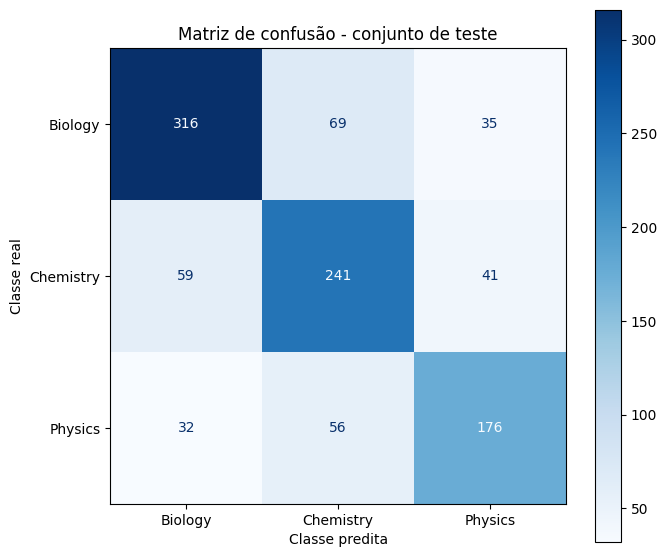

In [116]:
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=[
        "Biology",
        "Chemistry",
        "Physics"
    ]
)

fig, ax = plt.subplots(
    figsize=(7, 6)
)

disp.plot(
    ax=ax,
    cmap="Blues",
    values_format="d"
)

plt.title("Matriz de confusão - conjunto de teste")
plt.xlabel("Classe predita")
plt.ylabel("Classe real")
plt.tight_layout()
plt.show()

##### Imprimindo 10 textos e respectivas predições

Como nossa matriz de confusão apresenta 9 células, vamos escolher 1 elemento de cada célula. Para complementar, vamos selecionar o elemento que apresentou maior incerteza na escolha. Dessa forma teremos elementos suficientes para analisar qualitativamente o resultado obtido pelas predições do nosso modelo. Criamos algumas funções auxiliares para selecionar, formatar e exibir corretamente os exemplos desejados.

In [135]:
NOMES_CLASSES = {
    0: "Biology",
    1: "Chemistry",
    2: "Physics"
}

def normalizar_textos(X_test):
    """
    Converte os textos para um array unidimensional.
    """
    X_test_array = np.asarray(
        X_test
    )

    if X_test_array.ndim == 2:
        X_test_array = X_test_array[:, 0]

    if X_test_array.ndim != 1:
        raise ValueError(
            "X_test deve possuir formato (n,) ou (n, 1)."
        )

    return X_test_array


def tratar_texto(
    texto,
    preprocessor
):
    """
    Aplica o pré-processamento e converte o resultado para string.
    """
    return (
        preprocessor(texto)
        .numpy()
        .decode("utf-8")
    )


In [ ]:
def criar_registro_predicao(
    categoria,
    indice,
    X_test,
    y_true,
    y_pred,
    y_prob,
    classes,
    preprocessor
):
    """
    Cria o registro de uma predição selecionada.
    """
    registro = {
        "categoria": categoria,
        "índice no teste": indice,
        "valor verdadeiro": NOMES_CLASSES[
            y_true[indice]
        ],
        "classe predita": NOMES_CLASSES[
            y_pred[indice]
        ],
        "texto tratado": tratar_texto(
            X_test[indice],
            preprocessor
        )
    }

    for classe in classes:
        registro[
            f"probabilidade {NOMES_CLASSES[classe]}"
        ] = y_prob[
            indice,
            classe
        ]

    return registro


In [138]:
def selecionar_indice_celula_matriz(
    y_true,
    y_pred,
    classe_real,
    classe_predita,
    rng
):
    """
    Seleciona uma amostra de uma célula da matriz de confusão.
    """
    indices_disponiveis = np.where(
        (y_true == classe_real) &
        (y_pred == classe_predita)
    )[0]

    if len(indices_disponiveis) == 0:
        raise ValueError(
            "Não existem amostras disponíveis para: "
            f"classe real={NOMES_CLASSES[classe_real]}, "
            f"classe predita={NOMES_CLASSES[classe_predita]}."
        )

    return int(
        rng.choice(
            indices_disponiveis
        )
    )


def selecionar_indice_maior_incerteza(
    y_prob,
    indices_excluidos
):
    """
    Seleciona a predição com probabilidades mais equilibradas
    entre as classes utilizando a entropia.
    """
    probabilidades_seguras = np.clip(
        y_prob,
        1e-12,
        1.0
    )

    entropias = -np.sum(
        probabilidades_seguras *
        np.log(probabilidades_seguras),
        axis=1
    )

    entropias[
        indices_excluidos
    ] = -np.inf

    return int(
        np.argmax(
            entropias
        )
    )


In [139]:


def selecionar_predicoes_para_inspecao_multiclasse(
    X_test,
    y_true,
    y_pred,
    y_prob,
    preprocessor,
    random_state=RANDOM_STATE
):
    """
    Seleciona 10 predições representativas para inspeção manual:

    - 3 predições corretas, uma para cada classe;
    - 6 predições incorretas, uma para cada combinação possível
      entre classe real e classe predita;
    - 1 predição adicional com maior equilíbrio entre as
      probabilidades das classes.

    A última amostra é selecionada com base na maior entropia,
    correspondendo à predição com maior grau de incerteza.

    Parameters
    ----------
    X_test : pandas.Series ou numpy.ndarray
        Textos originais do conjunto de teste.

    y_true : array-like
        Classes verdadeiras.

    y_pred : array-like
        Classes preditas pelo modelo.

    y_prob : array-like
        Probabilidades estimadas para cada classe.
        Deve possuir formato:
        (quantidade_amostras, quantidade_classes).

    preprocessor : callable
        Função utilizada para tratar os textos.

    random_state : int
        Semente utilizada para garantir reprodutibilidade.

    Returns
    -------
    pandas.DataFrame
        Tabela contendo as amostras selecionadas.
    """
    rng = np.random.default_rng(
        random_state
    )

    X_test_array = normalizar_textos(
        X_test
    )

    y_true_array = np.asarray(
        y_true
    ).astype(int)

    y_pred_array = np.asarray(
        y_pred
    ).astype(int)

    y_prob_array = np.asarray(
        y_prob
    )

    classes = np.array([
        0,
        1,
        2
    ])

    combinacoes_corretas = [
        (classe, classe)
        for classe in classes
    ]

    combinacoes_incorretas = [
        (classe_real, classe_predita)
        for classe_real in classes
        for classe_predita in classes
        if classe_real != classe_predita
    ]

    registros = []
    indices_selecionados = []

    for classe_real, classe_predita in (
        combinacoes_corretas +
        combinacoes_incorretas
    ):
        indice = selecionar_indice_celula_matriz(
            y_true=y_true_array,
            y_pred=y_pred_array,
            classe_real=classe_real,
            classe_predita=classe_predita,
            rng=rng
        )

        indices_selecionados.append(
            indice
        )

        registros.append(
            criar_registro_predicao(
                categoria=(
                    f"Real {NOMES_CLASSES[classe_real]} "
                    f"→ Predita {NOMES_CLASSES[classe_predita]}"
                ),
                indice=indice,
                X_test=X_test_array,
                y_true=y_true_array,
                y_pred=y_pred_array,
                y_prob=y_prob_array,
                classes=classes,
                preprocessor=preprocessor
            )
        )

    indice_maior_incerteza = (
        selecionar_indice_maior_incerteza(
            y_prob=y_prob_array,
            indices_excluidos=indices_selecionados
        )
    )

    registros.append(
        criar_registro_predicao(
            categoria="Maior equilíbrio entre as classes",
            indice=indice_maior_incerteza,
            X_test=X_test_array,
            y_true=y_true_array,
            y_pred=y_pred_array,
            y_prob=y_prob_array,
            classes=classes,
            preprocessor=preprocessor
        )
    )

    return pd.DataFrame(
        registros
    )

Por fim exibimos os 10 textos selecionados seguindo os critérios estabelecidos.

In [134]:

df_predicoes_inspecao = (
    selecionar_predicoes_para_inspecao_multiclasse(
        X_test=X_test,
        y_true=y_test,
        y_pred=y_pred,
        y_prob=y_prob,
        preprocessor=Preprocessor
    )
)

pd.set_option("display.max_colwidth",None)
pd.set_option("display.float_format","{:.6f}".format)

df_predicoes_inspecao

,categoria,índice no teste,valor verdadeiro,classe predita,texto tratado,probabilidade Biology,probabilidade Chemistry,probabilidade Physics
0,Real Biology → Predita Biology,66,Biology,Biology,is one paper right there i dont know if there are any studies about this quite frankly it is up to us to push them to get this done im in a number of groups with postvaccine neuropathy and pretty much universally if you have the numb limbs for a few months you test positive for small fiber neuropathy biopsy so as far as claiming there are large numbers that is me but i can tell you its true that paper has been out for a number of months the author is in vermont you can email him i believe he is actually doing a study on it at the school but i have not talked to him myself one of the biggest problems is our database is fucked i filed a vaers report when this happened to me 6 months ago but i had no diagnosis you cannot update the report the cdc actually called me recently about that report and i said i have small fiber neuropathy ulnar neuropathy microvascular brain inflammation these are all provable and i have the tests guess what she refused everything she wouldnt take it she wouldnt write it down doesnt want to know anything about it told me to do a new report so i did another new vaers report so who the fuck is going to go ahead and do a brand new report every time a symptom comes in apparently thats what they want us to do so yeah basically people arent reporting it because they already did a report and now theyre getting the diagnosis five six months later and government is slow,0.903397,0.018770,0.077833
1,Real Chemistry → Predita Chemistry,810,Chemistry,Chemistry,oh thats an idea lol i had such a hatred of drycleaning that i didnt think of doing it again ill take a piece in and see if it works seeing as though id like to wash them in water would modern solvents react with water as well,0.006192,0.990977,0.002831
2,Real Physics → Predita Physics,680,Physics,Physics,theres an interesting neutron lifetime puzzle where different types of experiments measure different values for the lifetime bottle experiments like this one which measure neutrons that do not decay measure a lifetime about 10 s less than beam experiments which measure neutrons that do decay this could be due to experimental error or a 1 branching ratio to some exotic decay channel this result doesnt help resolve this puzzle improved precision helps probe ckm unitarity also the neutron lifetime is an important parameter in big bang nucleosynthesis because it determines the ratio of protons to neutrons prior to the beginning of formation of heavier nuclei the neutron source is rad hot we use a 800 mev proton beam to produce spallation neutrons and then cool them to ucn energy levels solid d2 is used in the final step to downscatter cold neutrons to ultracold neutrons this all happens under a shield stack of concrete and steel,0.000001,0.000006,0.999993
3,Real Biology → Predita Chemistry,456,Biology,Chemistry,right ive done spectrophotometry labs before and always did well on them the wording just threw me off here the light absorbance is messed up anyway my partner was running that part and i heard a few instances of which one did i just do so were gonna get burned on the part of the lab even with the concentrations done either way i mentioned the light absorbance is not linear with the changes in concentration idk how those values are so funky,0.273326,0.725931,0.000743
4,Real Biology → Predita Physics,408,Biology,Physics,interesting i went to austin peay in tennessee and uconn both made me choose a discipline i had to take the courses for that and anything else had to be elective cool you can just take whatever interests you,0.142806,0.092571,0.764623
5,Real Chemistry → Predita Biology,877,Chemistry,Biology,damn technology is amazing but kids these days wont know the struggle of tryna figure this shit out by hand,0.911057,0.015439,0.073504
6,Real Chemistry → Predita Ph

Podemos observar que o modelo classifica muito bem os textos que apresentam grande ocorrência de palavras técnicas relacionadas a cada domínio. Já nos textos que foram incorretamente classificados podemos observar que existem palavras que podem pertencer a mais de um dominio, ou cujo texto não permite determinar o contexto com precisão. Por fim, o texto de maior incerteza é simplesmente uma frase bem concisa de agradecimento, que não traz qualquer tipo de informação relevante para determinar o contexto.

Dessa forma, podemos dizer que o modelo funciona bem, e que os erros de classificação não estão exclusivamente relacionados a qualidade do modelo ou do treinamento, mas também estão relacionados a textos com pouca ou nenhuma relação com as classes da tarefa proposta.

### **7º Passo:**
<font size=3>

- Faça o **relatório da modelagem da arquitetura neural** em uma **célula _markdown_**.
      

Na primeira etapa, foi realizada uma busca aleatória de hiperparâmetros para explorar diferentes configurações de redes recorrentes. Foram avaliadas combinações com camadas `LSTM` e `GRU`, em versões unidirecionais e bidirecionais, variando-se a quantidade de unidades recorrentes, a taxa de *dropout*, o otimizador e a taxa de aprendizado. A camada `SimpleRNN`, inicialmente considerada, foi retirada da busca devido ao custo computacional observado durante os testes preliminares. Nessa etapa, a dimensão do *embedding* foi fixada em 100 e a camada densa em 32 unidades. A melhor configuração encontrada utilizou `Bidirectional(LSTM)` com 64 unidades, `dropout` de 0,2, otimizador `Adam` e taxa de aprendizado de `10^{-3}`, alcançando acurácia de validação de aproximadamente 0,7436. Os resultados também indicaram desempenho consistentemente superior do `Adam` em relação ao `RMSprop`, além de maior concentração dos melhores resultados nas arquiteturas bidirecionais.

Na segunda etapa, foi realizada uma busca em grade mais restrita, concentrada nas duas arquiteturas mais promissoras da etapa anterior: `Bidirectional(LSTM)` com 64 unidades e `Bidirectional(GRU)` com 32 unidades. Foram avaliadas diferentes dimensões de *embedding* (`100`, `150` e `200`), quantidades de unidades na camada densa (`32` e `64`) e taxas de *dropout* (`0,2` e `0,4`), mantendo-se fixos o otimizador `Adam` e a taxa de aprendizado de `10^{-3}`. A melhor configuração utilizou `Embedding(150)`, `Bidirectional(LSTM(64))`, `Dense(32)` e `Dropout(0,4)`, atingindo acurácia de validação de 0,7458 na época 11. A comparação entre os modelos mostrou que o aumento do *embedding* para 150 trouxe ganho em relação ao valor inicial, enquanto o uso de 200 dimensões e a ampliação da camada densa para 64 unidades não produziram melhoria adicional. Dessa forma, essa configuração foi selecionada para o treinamento final com todo o conjunto disponível de treino e validação.
